# Vorlage Plausi-Tests
## Ausländische Bevölkerung nach Jahr, Nationalität und Geschlecht (historische Daten)
### Kurzbeschreibung
Anzahl Personen der ausländischen Wohnbevölkerung nach Jahr, Nationalität (ausgewählte Nationalitäten) und Geschlecht.

Datum: 29.01.2026


Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bev_bestand_nationen_geschlecht_hist_jahr_od3485

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_nationen_geschlecht_hist_jahr_od3485


### Importiere die notwendigen Packages

In [270]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [271]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Welche Python, Altair und Seaborn Version wird verwendet?

In [272]:
#base env 2025: Python 3.11.7
import ipykernel
print(ipykernel.__version__)

import sys
import platform
print("Python-Version:", sys.version)
print("Python-Implementierung:", platform.python_implementation())
print("Python-Build:", platform.python_build())
print("Python-Compiler:", platform.python_compiler())

print("Altair-Version:", alt.__version__)
print("Seaborn-Version:", sns.__version__)

6.29.3
Python-Version: 3.11.8 | packaged by Anaconda, Inc. | (main, Feb 26 2024, 21:34:05) [MSC v.1916 64 bit (AMD64)]
Python-Implementierung: CPython
Python-Build: ('main', 'Feb 26 2024 21:34:05')
Python-Compiler: MSC v.1916 64 bit (AMD64)
Altair-Version: 5.0.1
Seaborn-Version: 0.12.2


Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [273]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [274]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [275]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [276]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Paletten aus Zuericolors
Die Farbwerte habe ich aus R ausgelesen. Siehe dazu: `G:\sszsim\myR\zuericolors4python`

In [277]:
# Quantitative Paletten
zuericolors_qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
zuericolors_qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
zuericolors_qual12da= ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
# Divergente Paletten
zuericolors_div9val  =  ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A"] 
zuericolors_div9ntr  =  ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB"] 
# Geschlechter Paletten
zuericolors_gender3  =  ["#349894", "#FFD736", "#986AD5"] 
zuericolors_gender6origin  =  ["#00615D", "#349894", "#DA9C00", "#FFD736", "#5E359A", "#986AD5"] 
zuericolors_gender5wedding  =  ["#349894", "#FFD736", "#3431DE", "#B8B8B8", "#D6D6D6"] 
# Sequenzielle Paletten
zuericolors_seq9blu  =  ["#CADEFF", "#AEC2FF", "#93A6FF", "#778AFF", "#5B6EFF", "#4D59E2", "#3E44C5", "#302FA7", "#211A8A"] 
zuericolors_seq9red  =  ["#FED2EE", "#FEAED6", "#F589BE", "#F165A5", "#ED408D", "#D1307B", "#B52069", "#991056", "#7D0044"] 
zuericolors_seq9grn  =  ["#CFEED8", "#A8E0B3", "#81D18F", "#5BC36A", "#34B446", "#2A9A3C", "#208032", "#166529", "#0C4B1F"] 
zuericolors_seq9brn  =  ["#FCDDBB", "#F7BD8C", "#F39D5E", "#EE7D2F", "#EA5D00", "#C84E00", "#A53E00", "#832F00", "#611F00"]

#### Zeitvariabeln


In [278]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [279]:
package_name = "bev_bestand_nationen_geschlecht_hist_jahr_od3485"

In [280]:
data2betested = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV348OD3485"    
    , datums_attr = ['StichtagDatJahr']
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_nationen_geschlecht_hist_jahr_od3485/download/BEV348OD3485.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_nationen_geschlecht_hist_jahr_od3485 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_bestand_nationen_geschlecht_hist_jahr_od3485 

data_source: web


In [281]:
data2betested.head(2).T

,0,1
StichtagDatJahr,1894-01-01 00:00:00,1900-01-01 00:00:00
NationHistCd,8207,8207
NationHistLang,Deutschland,Deutschland
SexCd,2,2
SexLang,weiblich,weiblich
AnzBestWir,12443,17301


Berechne weitere Attribute falls notwendig

In [282]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_end = lambda x: x.StichtagDatJahr+pd.offsets.YearEnd(0),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr        datetime64[ns]
NationHistCd                    int64
NationHistLang                 object
SexCd                           int64
SexLang                        object
AnzBestWir                      int64
StichtagDatJahr_str            object
Jahr                   datetime64[ns]
Jahr_end               datetime64[ns]
Jahr_nbr                        int32
dtype: object

Minimales und maximales Jahr im Datensatz

In [283]:
data_max_jahr = str(max(data2betested.Jahr).year)
data_min_jahr = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_jahr} und ein Maximumjahr von {data_max_jahr}")

Die Daten haben ein Minimumjahr von 1894 und ein Maximumjahr von 2024


In [284]:
data_max_date = max(data2betested.Jahr_end).strftime('%Y-%m-%d')
data_min_date = min(data2betested.Jahr_end).strftime('%Y-%m-%d')


print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1894-12-31 und ein Maximumjahr von 2024-12-31


### Einfache Datentests

In [285]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1658 entries, 49 to 0
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   StichtagDatJahr      1658 non-null   datetime64[ns]
 1   NationHistCd         1658 non-null   int64         
 2   NationHistLang       1658 non-null   object        
 3   SexCd                1658 non-null   int64         
 4   SexLang              1658 non-null   object        
 5   AnzBestWir           1658 non-null   int64         
 6   StichtagDatJahr_str  1658 non-null   object        
 7   Jahr                 1658 non-null   datetime64[ns]
 8   Jahr_end             1658 non-null   datetime64[ns]
 9   Jahr_nbr             1658 non-null   int32         
dtypes: datetime64[ns](3), int32(1), int64(3), object(3)
memory usage: 444.6 KB


In [286]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 1,658 rows (observations) and 10 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [287]:
data2betested.describe()

,StichtagDatJahr,NationHistCd,SexCd,AnzBestWir,Jahr,Jahr_end,Jahr_nbr
count,1658,1658,1658,1658,1658,1658,1658
mean,1990-06-14 16:54:25.621230336,8222,2,2012,1990-06-14 16:54:25.621230336,1991-06-13 22:31:24.680337792,1990
min,1894-01-01 00:00:00,8204,1,0,1894-01-01 00:00:00,1894-12-31 00:00:00,1894
25%,1993-01-01 00:00:00,8212,1,139,1993-01-01 00:00:00,1993-12-31 00:00:00,1993
50%,2004-01-01 00:00:00,8223,2,489,2004-01-01 00:00:00,2004-12-31 00:00:00,2004
75%,2014-01-01 00:00:00,8231,2,2232,2014-01-01 00:00:00,2014-12-31 00:00:00,2014
max,2024-01-01 00:00:00,8240,2,22706,2024-01-01 00:00:00,2024-12-31 00:00:00,2024
std,NaN,11,1,3639,NaN,NaN,37


Welches sind die Quartiere ohne Werte bei BEW?

In [288]:
data2betested[np.isnan(data2betested.AnzBestWir)]

,StichtagDatJahr,NationHistCd,NationHistLang,SexCd,SexLang,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [289]:
data2betested = data2betested.set_index("StichtagDatJahr")
data2betested = data2betested.sort_index()

In [290]:
data2betested.index.year.unique()

Index([1894, 1900, 1905, 1906, 1907, 1908, 1909, 1910, 1911, 1913, 1914, 1915, 1916, 1917, 1918,
       1919, 1920, 1930, 1941, 1950, 1960, 1970, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996,
       1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
      dtype='int32', name='StichtagDatJahr')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [291]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number')) #,datetime_is_numeric=True
except:
    print("No categorical data in dataset.")

,NationHistLang,SexLang,StichtagDatJahr_str,Jahr,Jahr_end
count,1658,1658,1658,1658,1658
unique,21,2,58,NaN,NaN
top,Deutschland,weiblich,1894-01-01,NaN,NaN
freq,100,829,40,NaN,NaN
mean,NaN,NaN,NaN,1990-06-14 16:54:25.621230336,1991-06-13 22:31:24.680337664
min,NaN,NaN,NaN,1894-01-01 00:00:00,1894-12-31 00:00:00
25%,NaN,NaN,NaN,1993-01-01 00:00:00,1993-12-31 00:00:00
50%,NaN,NaN,NaN,2004-01-01 00:00:00,2004-12-31 00:00:00
75%,NaN,NaN,NaN,2014-01-01 00:00:00,2014-12-31 00:00:00
max,NaN,NaN,NaN,2024-01-01 00:00:00,2024-12-31 00:00:00


Beschreibe numerische Attribute

In [292]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,NationHistCd,SexCd,AnzBestWir,Jahr_nbr
count,"1,658","1,658","1,658","1,658"
mean,"8,222",2,"2,012","1,990"
std,11,1,"3,639",37
min,"8,204",1,0,"1,894"
25%,"8,212",1,139,"1,993"
50%,"8,223",2,489,"2,004"
75%,"8,231",2,"2,232","2,014"
max,"8,240",2,"22,706","2,024"


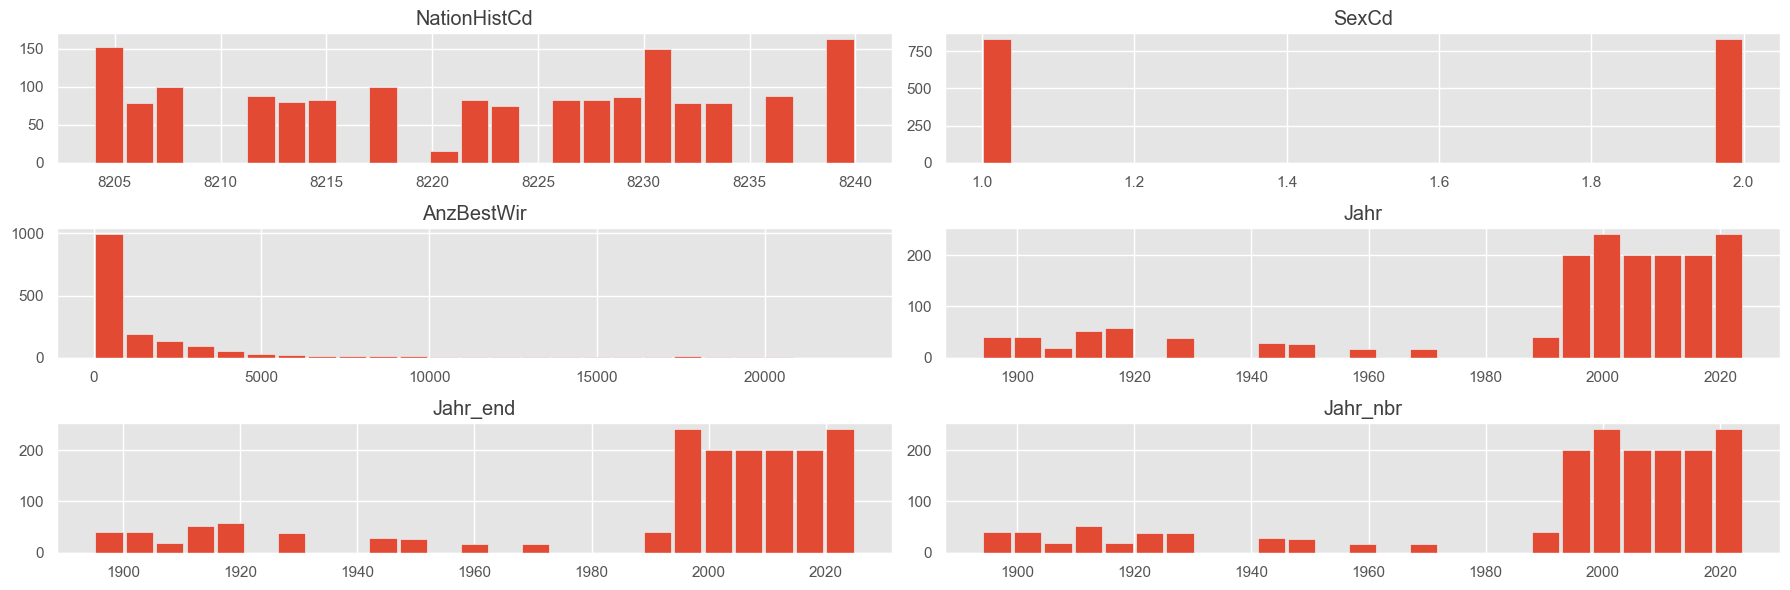

In [293]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [294]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,NationHistCd,NationHistLang,SexCd,SexLang,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
StichtagDatJahr,,,,,,,,,


### Nullwerte und Missings?

In [295]:
data2betested.isnull().sum()

NationHistCd           0
NationHistLang         0
SexCd                  0
SexLang                0
AnzBestWir             0
StichtagDatJahr_str    0
Jahr                   0
Jahr_end               0
Jahr_nbr               0
dtype: int64

In [296]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [297]:
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr', 'Jahr_nbr', 'Jahr_end']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('Jahr', ascending=False) 
agg_jahr.reset_index().head(3)

,Jahr,Jahr_nbr,Jahr_end,sum_AnzBestWir
0,2024-01-01,2024,2024-12-31,100166
1,2023-01-01,2023,2023-12-31,99210
2,2022-01-01,2022,2022-12-31,97176


In [298]:
agg_nation = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['NationHistCd', 'NationHistLang']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('NationHistCd', ascending=False) 
agg_nation.reset_index().head(3)

,NationHistCd,NationHistLang,sum_AnzBestWir
0,8240,Ungarn,35379
1,8239,Türkei,154020
2,8236,Spanien,244128


In [336]:
agg_sex = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['SexCd', 'SexLang']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('SexCd', ascending=False) 
agg_sex.reset_index().head(10)

,SexCd,SexLang,sum_AnzBestWir
0,2,weiblich,1540947
1,1,männlich,1761594


### Pivotiere

In [300]:
pivoted_df = data2betested.pivot_table(
    index='Jahr_nbr',
    columns= ('SexLang', 'NationHistCd', 'NationHistLang'),
    values='AnzBestWir',
    aggfunc='sum'
)

# Sortieren nach der Aggregation 
#pivoted_df = pivoted_df.sort_values(by=pivoted_df.index[-1], axis=1, ascending=False)

# Sortieren der Zeilen (Jahre) in absteigender Reihenfolge
pivoted_df = pivoted_df.sort_index(ascending=False)

# Anzeigen des Ergebnisses
print(pivoted_df.head(8).T)

Jahr_nbr                               2024  2023  2022  2021  2020  2019  2018  2017
SexLang  NationHistCd NationHistLang                                                 
männlich 8204         Belgien           622   555   541   519   490   447   434   395
         8205         Bulgarien         457   434   397   367   336   317   285   264
         8206         Dänemark          251   257   254   224   214   235   222   227
         8207         Deutschland     17614 17664 17502 17349 17761 18050 18171 18271
         8212         Frankreich       3332  3313  3267  3080  2932  2830  2692  2555
         8214         Griechenland     2047  1979  1856  1757  1671  1604  1518  1412
         8215         Grossbritannien  1869  1964  2084  2210  2419  2343  2267  2245
         8218         Italien         10232 10038  9730  9301  9100  9073  8820  8640
         8220         Jugoslawien       NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
         8222         Liechtenstein     220   224   22

### Visualisierungen nach Zeitausschnitten

#### Entwicklung der ausländischen Wohnbevölkerung nach Nationalität

In [301]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg1 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'NationHistCd', 'NationHistLang']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAgg1.reset_index().head(3)

,StichtagDatJahr,NationHistCd,NationHistLang,sum_WBev
0,1900-01-01,8204,Belgien,42
1,1900-01-01,8239,Türkei,53
2,1900-01-01,8236,Spanien,102


In [302]:
#help(mypy_dv.plot_altair_multiline_highlight)

In [303]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index().sort_values('NationHistCd', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'sum_WBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "NationHistLang:N"
    ,category_beschriftung= 'Legende:'
    ,x_sort = None
    ,palette_scheme = None # 'turbo','viridis','category20b','category20c', 'tableau20', 'sinebow', 'rainbow, 'dark2', 'inferno',
    ,custom_palette = zuericolors_qual12+zuericolors_gender6origin
    ,line_width = 1.1                 
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der ausländischen Wohnbevölkerung nach Nationalität, seit "+str(int(data2betested.index.year.min()))
)
grafik1

alt.LayerChart(...)

#### Entwicklung nach Geschlecht

In [304]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg2 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'SexCd', 'SexLang']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAgg2.reset_index().head(3)

,StichtagDatJahr,SexCd,SexLang,sum_WBev
0,1900-01-01,1,männlich,20541
1,1900-01-01,2,weiblich,21817
2,1905-01-01,1,männlich,19795


In [305]:
grafik2 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg2.reset_index().sort_values('SexCd', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'sum_WBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "SexLang:N"
    ,category_beschriftung= 'Legende:'
    ,custom_palette = zuericolors_gender3
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der ausländischen Wohnbevölkerung nach Geschlecht, seit "+str(int(data2betested.index.year.min()))
)
grafik2

alt.LayerChart(...)

##### Kombinierte Grafik in Altair

In [306]:
# Kombiniere die Grafiken horizontal
top_row = alt.hconcat(grafik1, grafik2)
#combined_chart = alt.vconcat(top_row,grafik3)
combined_chart = alt.vconcat(grafik1, grafik2, spacing=20)

# Optional: Füge einen Titel für die gesamte Grafik hinzu
final_chart = combined_chart.properties(
    title="   ",  
    background="#FDFDFD",
    padding={"left": 20, "top": 20, "right": 20, "bottom": 20},
    autosize={"type": "fit", "contains": "padding"}
)
#Legenden nicht zusammenfügen
final_chart = final_chart.resolve_scale(
    color='independent',
    shape='independent',
    size='independent'
)

# Zeigen Sie die Grafik an
final_chart

alt.VConcatChart(...)

#### Barcharts mit Seaborn

In [307]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAggBar = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'NationHistCd', 'NationHistLang', 'Jahr', 'Jahr_end', 'Jahr_nbr']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAggBar.reset_index().head(3)

,StichtagDatJahr,NationHistCd,NationHistLang,Jahr,Jahr_end,Jahr_nbr,sum_WBev
0,1900-01-01,8204,Belgien,1900-01-01,1900-12-31,1900,42
1,1900-01-01,8239,Türkei,1900-01-01,1900-12-31,1900,53
2,1900-01-01,8236,Spanien,1900-01-01,1900-12-31,1900,102


In [308]:
#help(sns.catplot)   

# #Stile for the following sns graphs
sns.set_theme(style="whitegrid")

##### Stacked Bar Chart

In [309]:
myAggBar.reset_index().head(2)

,StichtagDatJahr,NationHistCd,NationHistLang,Jahr,Jahr_end,Jahr_nbr,sum_WBev
0,1900-01-01,8204,Belgien,1900-01-01,1900-12-31,1900,42
1,1900-01-01,8239,Türkei,1900-01-01,1900-12-31,1900,53


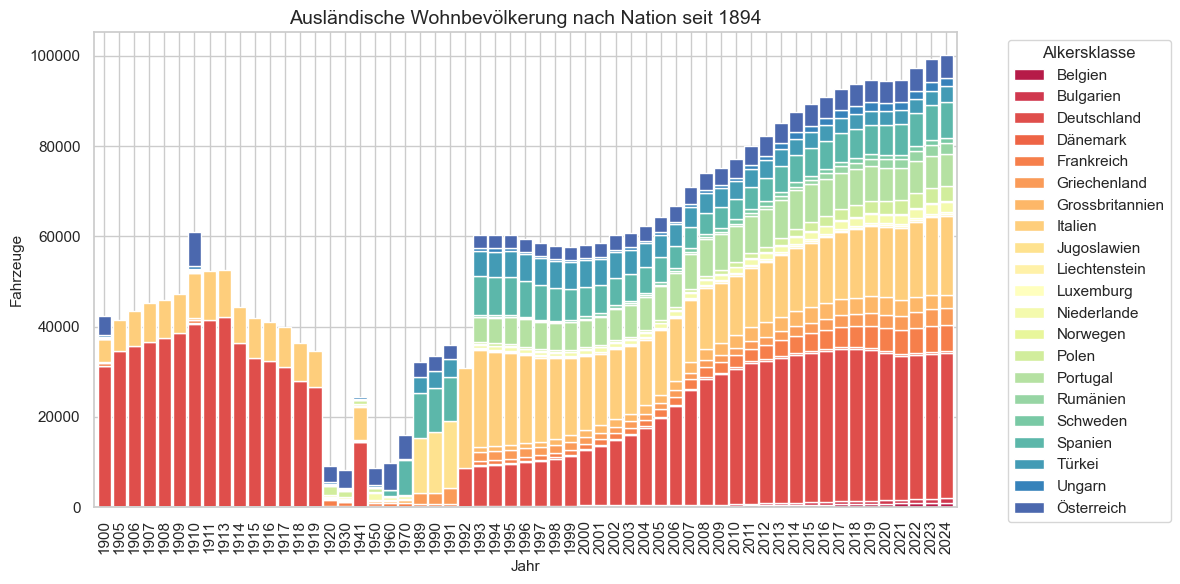

In [ ]:
# Daten vorbereiten

data = myAggBar.query("sum_WBev > 0").reset_index()
data_pivoted = data.pivot(index='Jahr_nbr', columns='NationHistLang', values='sum_WBev').fillna(0)

# Farbpalette erstellen
colors = sns.color_palette("Spectral", n_colors=len(data_pivoted.columns)) #"flare" / "vlag" / "icefire" / "Spectral", "cubehelix"
# Figur und Achsen erstellen
fig, ax = plt.subplots(figsize=(12, 6))
# Gestapeltes Balkendiagramm zeichnen
data_pivoted.plot(
    kind='bar', 
    stacked=True, 
    ax=ax, 
    color=colors,
    width=0.9
    )
# Titel hinzufügen
plt.title('Ausländische Wohnbevölkerung nach Nation seit ' + str(int(data2betested.index.year.min())), fontsize=14)
# Achsenbeschriftungen anpassen
ax.set_xlabel('Jahr', fontsize=11)
ax.set_ylabel('Fahrzeuge', fontsize=11)

# Legende anpassen
plt.legend(title='Alkersklasse', bbox_to_anchor=(1.05, 1), loc='upper left')
# Layout anpassen
plt.tight_layout()
# Diagramm anzeigen
plt.show()

In [311]:
data2betested.columns

Index(['NationHistCd', 'NationHistLang', 'SexCd', 'SexLang', 'AnzBestWir', 'StichtagDatJahr_str',
       'Jahr', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

#### Faced Grids

In [312]:
myFG = data2betested.sort_values('NationHistCd', ascending=True) 
myFG

,NationHistCd,NationHistLang,SexCd,SexLang,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
StichtagDatJahr,,,,,,,,,
2015-01-01,8204,Belgien,1,männlich,344,2015-01-01,2015-01-01,2015-12-31,2015
1910-01-01,8204,Belgien,1,männlich,29,1910-01-01,1910-01-01,1910-12-31,1910
1999-01-01,8204,Belgien,1,männlich,91,1999-01-01,1999-01-01,1999-12-31,1999
2013-01-01,8204,Belgien,2,weiblich,187,2013-01-01,2013-01-01,2013-12-31,2013
2013-01-01,8204,Belgien,1,männlich,263,2013-01-01,2013-01-01,2013-12-31,2013
...,...,...,...,...,...,...,...,...,...
1941-01-01,8240,Ungarn,2,weiblich,159,1941-01-01,1941-01-01,1941-12-31,1941
1997-01-01,8240,Ungarn,1,männlich,347,1997-01-01,1997-01-01,1997-12-31,1997
1997-01-01,8240,Ungarn,2,weiblich,257,1997-01-01,1997-01-01,1997-12-31,1997


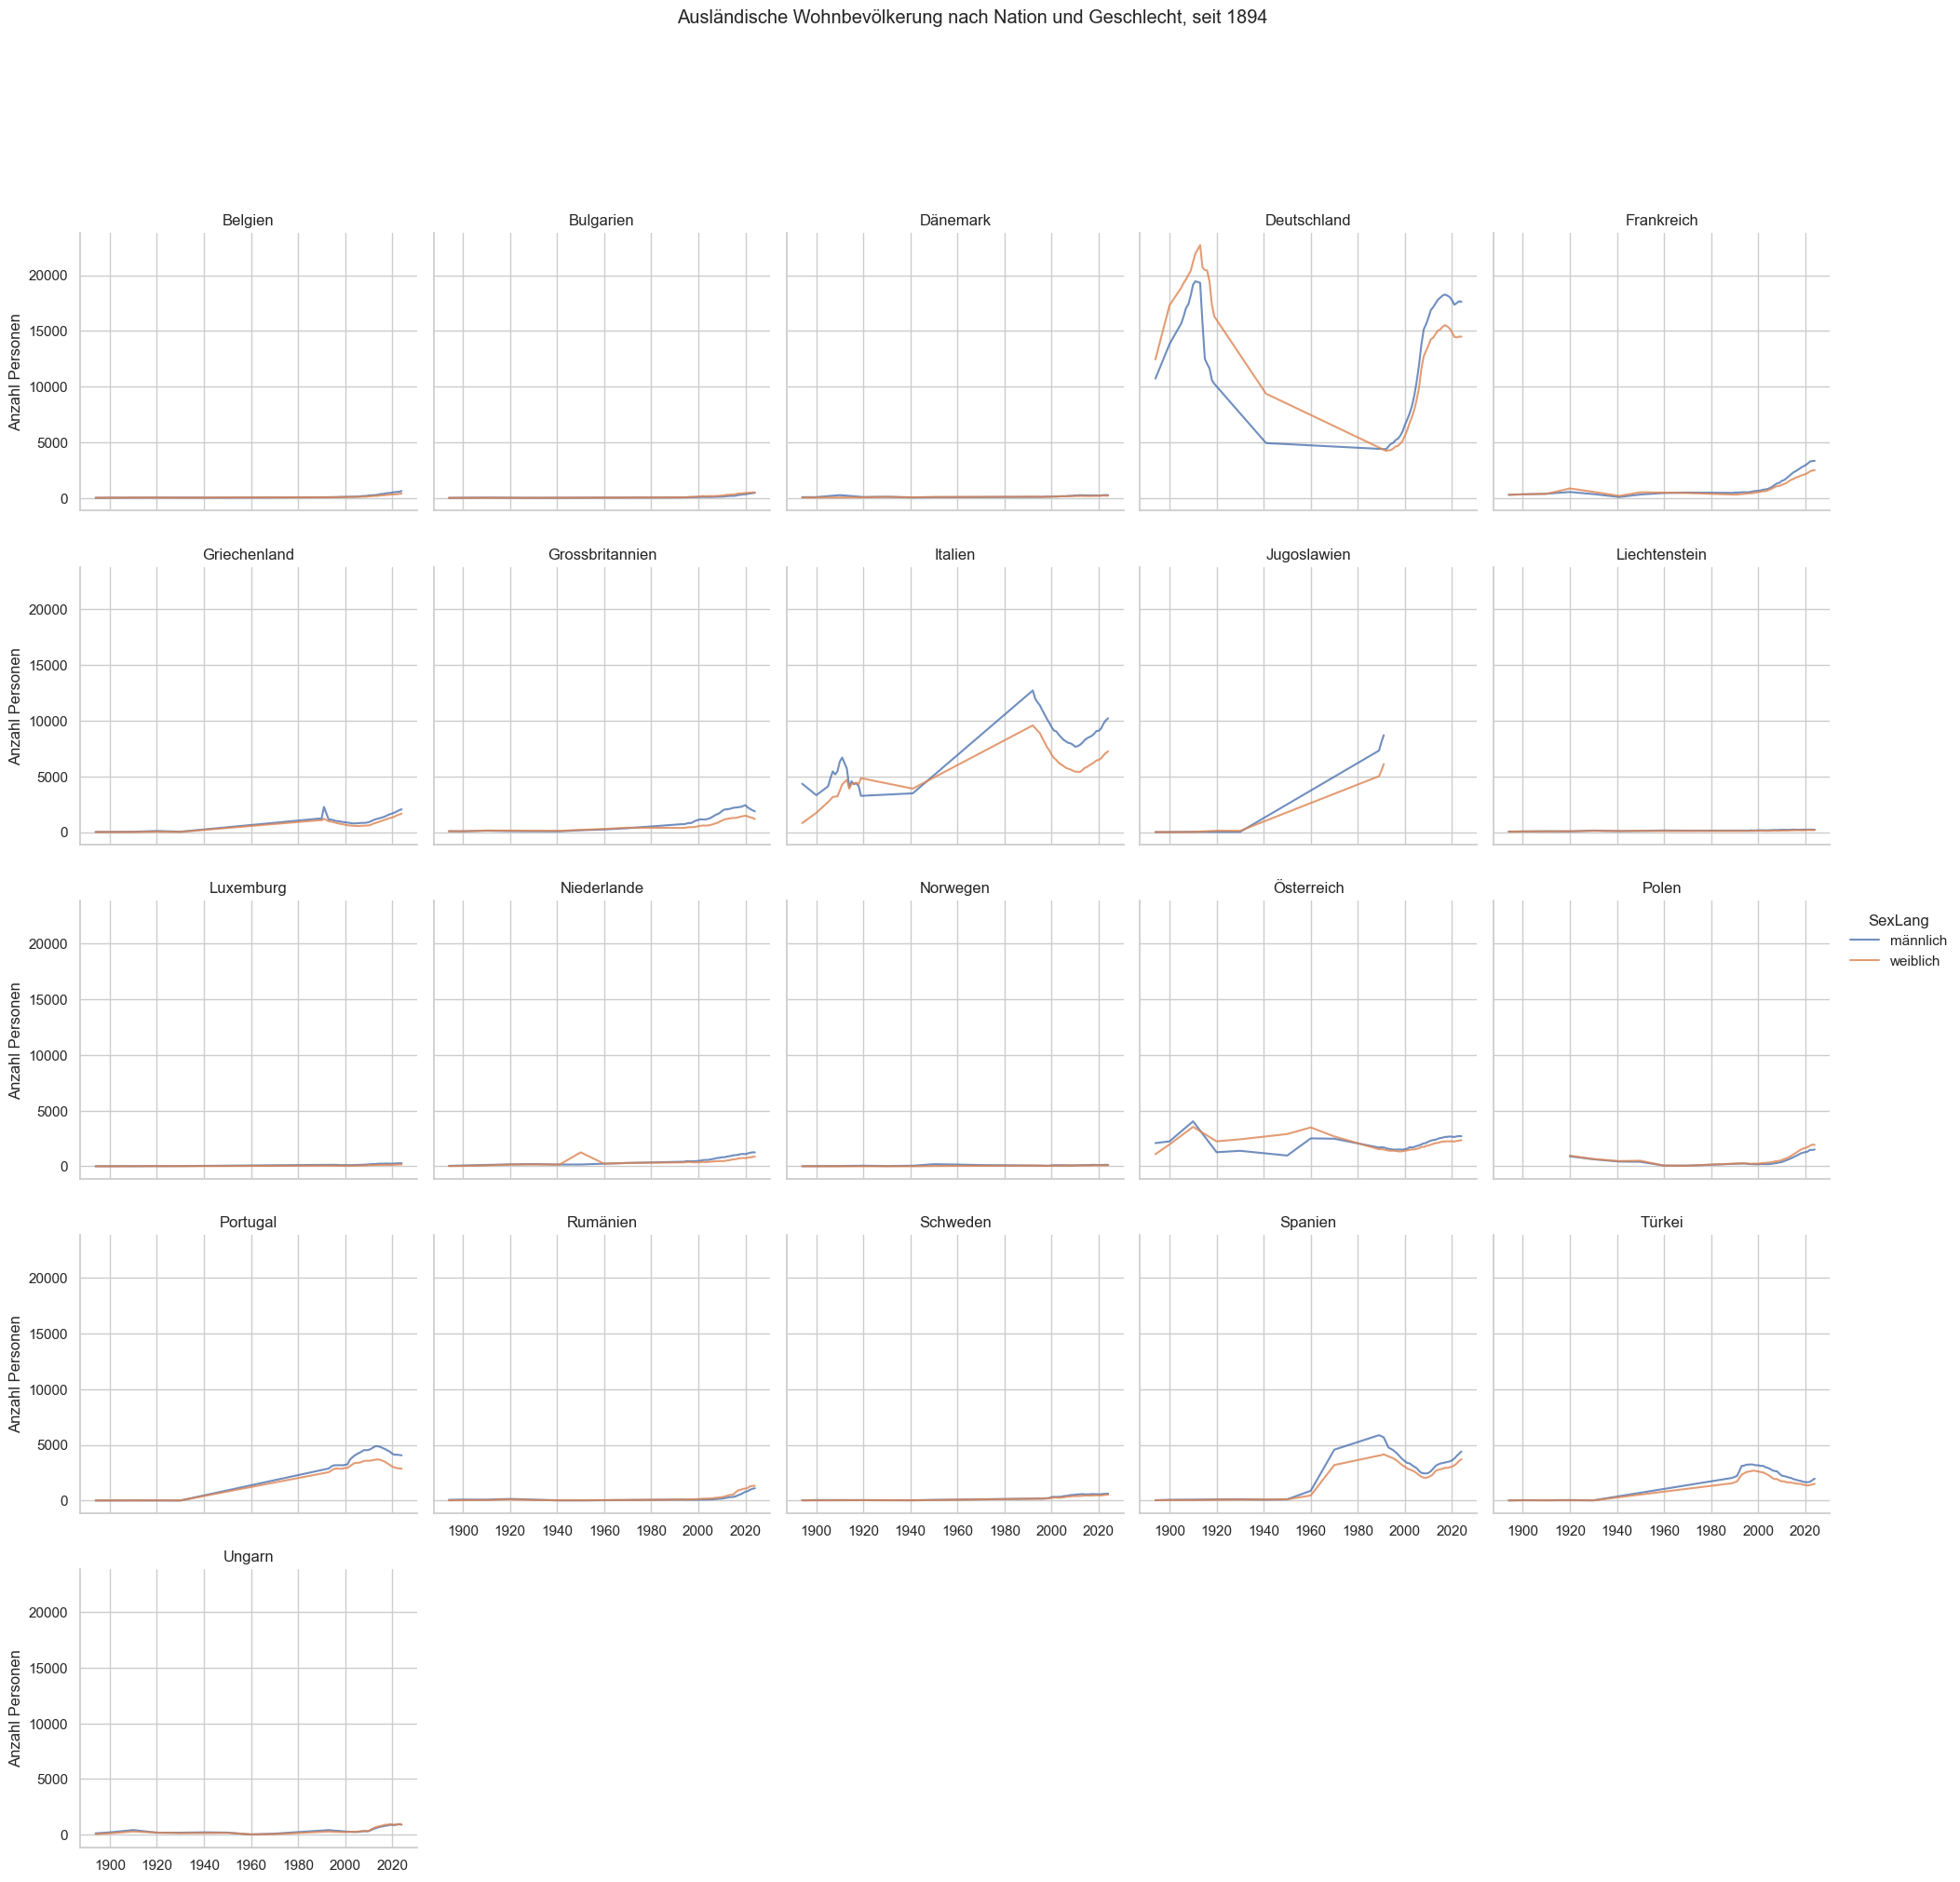

In [313]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = myFG.reset_index().sort_values('NationHistCd', ascending=True)
    ,col = "NationHistLang"
    ,hue = "SexLang"
    ,col_wrap = 5
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "AnzBestWir"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Ausländische Wohnbevölkerung nach Nation und Geschlecht, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [314]:
# Extrahiere die Top-Fahrzeugmarken
zuzugsgebiet = data2betested['NationHistLang'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = zuericolors_qual12 + zuericolors_qual12da + zuericolors_qual12br +  zuericolors_div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(zuzugsgebiet):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', 'Deutschland': '#3431DE', 'Österreich': '#0A8DF6', 'Portugal': '#23C3F1', 'Türkei': '#7B4FB7', 'Bulgarien': '#DB247D', 'Frankreich': '#FB737E', 'Jugoslawien': '#007C78', 'Dänemark': '#1F9E31', 'Belgien': '#99C32E', 'Grossbritannien': '#9A5B01', 'Luxemburg': '#FF720C', 'Liechtenstein': '#FBB900', 'Ungarn': '#0017BF', 'Italien': '#0072D7', 'Niederlande': '#00A5D2', 'Spanien': '#5E359A', 'Rumänien': '#BA0062', 'Schweden': '#DA5563', 'Norwegen': '#00615D', 'Griechenland': '#00770F', 'Polen': '#7BA600'}


##### Ausländische Wohnbevölkerung nach Nation und Geschlecht

In [333]:
#myTM = data2betested.loc[data_max_jahr].reset_index() \
myTM = data2betested.loc[(data2betested.index.year == 1910)|(data2betested.index.year == 2024)].reset_index()
myTM.reset_index().head(2)

,index,StichtagDatJahr,NationHistCd,NationHistLang,SexCd,SexLang,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
0,0,1910-01-01,8205,Bulgarien,1,männlich,35,1910-01-01,1910-01-01,1910-12-31,1910
1,1,1910-01-01,8204,Belgien,2,weiblich,35,1910-01-01,1910-01-01,1910-12-31,1910


In [329]:
data2betested.columns

Index(['NationHistCd', 'NationHistLang', 'SexCd', 'SexLang', 'AnzBestWir', 'StichtagDatJahr_str',
       'Jahr', 'Jahr_end', 'Jahr_nbr'],
      dtype='object')

In [334]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=myTM.reset_index()
    ,levels=['Jahr_nbr','NationHistLang','SexLang']
    ,values="AnzBestWir"
    ,color="AnzBestWir"
    #, color_continuous_scale='Blues'
    ,color_discrete_map={'(?)':'lightgrey', 'Wohnen':'lightblue'}   
    ,height=400
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Ausländische Wohnbevölkerung nach Nation und Geschlecht, "+str(myTM.reset_index().Jahr_nbr.min()) +" und " +str(myTM.reset_index().Jahr_nbr.max())
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x000001D615B55E50>, 'Jahr_nbr', 'NationHistLang', 'SexLang']
Typ von path: <class 'list'>


##### Ausländische Wohnbevölkerung nach Nation und Geschlecht

In [335]:
treeMap2= mypy_dv.plot_px_treemap(
    data=myTM.reset_index()
    ,levels=['SexLang','NationHistLang','Jahr_nbr']
    ,values="AnzBestWir"
    ,color="NationHistLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map={'(?)':'lightgrey', 'Wohnen':'lightblue'}   
    ,height=400
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Ausländische Wohnbevölkerung nach Nation und Geschlecht, "+str(myTM.reset_index().Jahr_nbr.min()) +" und " +str(myTM.reset_index().Jahr_nbr.max())
)
treeMap2

path: [<plotly.express._special_inputs.Constant object at 0x000001D6161141D0>, 'SexLang', 'NationHistLang', 'Jahr_nbr']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://szhglobal.sharepoint.com/sites/ssz-spo-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=1693&e=7n2HKO)**

---------------------------------------------------------------------------